c:\Users\ionut\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Începere antrenare...
Antrenare finalizată!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


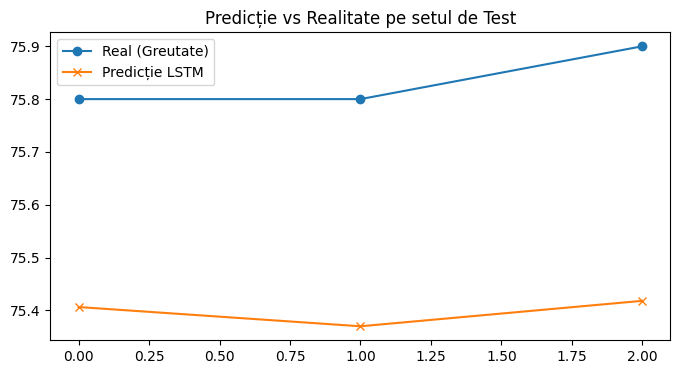

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Preprocesare Date
# Încărcarea datelor ARFF (salvate cu extensia .csv)
file_path = 'data/gym_progress_cleaned.csv'

with open(file_path, 'r') as f:
    lines = f.readlines()

# Găsim linia cu @DATA
data_start = next(i for i, line in enumerate(lines) if line.strip() == '@DATA')

# Citim datele după @DATA
data_lines = lines[data_start + 1:]

# Parsează fiecare linie
rows = []
for line in data_lines:
    if line.strip():
        # Eliminate comillas și parsează valorile
        values = line.strip().replace("'", "").split(',')
        rows.append(values)

# Creează DataFrame
df = pd.DataFrame(rows, columns=['Date', 'Workout_Duration', 'Caloric_Intake', 'Protein_Intake', 'Weight'])

# Convertesc tipurile de date
df['Date'] = pd.to_datetime(df['Date'])
df['Workout_Duration'] = df['Workout_Duration'].astype(float)
df['Caloric_Intake'] = df['Caloric_Intake'].astype(float)
df['Protein_Intake'] = df['Protein_Intake'].astype(float)
df['Weight'] = df['Weight'].astype(float)

df = df.set_index('Date')

features = ['Workout_Duration', 'Caloric_Intake', 'Protein_Intake']
target = ['Weight']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaled_X = scaler_X.fit_transform(df[features])
scaled_y = scaler_y.fit_transform(df[target])

def create_sequences(X, y, time_steps=3):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 3 # Folosim 3 zile pt ca setul mock e mic (15 zile)
X, y = create_sequences(scaled_X, scaled_y, TIME_STEPS)

# Împărțire train/test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 2. Arhitectura LSTM
model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# 3. Antrenare
print("Începere antrenare...")
history = model.fit(X_train, y_train, epochs=50, batch_size=4, validation_split=0.1, verbose=0)
print("Antrenare finalizată!")

# 4. Evaluare și Predicție
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

plt.figure(figsize=(8, 4))
plt.plot(y_test_actual, label='Real (Greutate)', marker='o')
plt.plot(y_pred, label='Predicție LSTM', marker='x')
plt.title('Predicție vs Realitate pe setul de Test')
plt.legend()
plt.show()

# Creare folder models (dacă nu există) și salvare model
import os
os.makedirs('models', exist_ok=True)
model.save('models/lstm_muscle_progression.h5')